# **Capstone project: Providing data-driven suggestions for HR**

## Project Summary

Salifort Motors is experiencing an operational decay due to an unsustainable working culture and stagnating employees. The analysis in this project shows that Salifort Motors normalizes an unhealthy grind culture, with the majority of employees working above the legal limit of overtime set by the French Government. The company's evaluation metrics show a significant correlation to high workload and long working hours, with severe overworkers dominating as high performers compared to the rest. While high output is theoretically achievable within standard hours, in practice, exceeding standard working hours has become a near-mandatory threshold for achieving a positive score. On top of that, Salifort Motors is showing stagnation and promotion bottlenecks across all departments, with only ~1.6% promotions within the last 5 years. These issues cascade into an expectation mismatch that causes attrition as the company fails to be accountable for the employee's interest and health.

It is highly recommended that Salifort Motors rectify the underlying problems before a prediction model can be faithfully designed. These key actions will be a better solution for all parties involved:
* **Revising HR Policies**: Implement strict, systemic overtime guardrails to align with French labor regulations. Performance evaluation methodologies must re-center around healthy working standards to actively prevent burnout.
* **Revising Promotion Brackets**: Layering and implementing a different promotion framework, such as broadbanding, and creating interim roles can offer meaningful lateral mobility, continuous professional development, and financial growth for employees

The ethical implications for an attrition prediction model are the possible misuse, intentionally or unintentionally, of the model in such ways:
* **Unfair incentives to retain employees**: The model might be used strictly to incentivize employees without rectifying humanitarian policies.
* **Dehumanizing outcomes:**: The model risks being used to manage individual employees through incentives rather than addressing systemic problems, treating retention as a technical problem instead of a management accountability issue.

## **PACE stages**
This project uses the **PACE** Framework for analysis

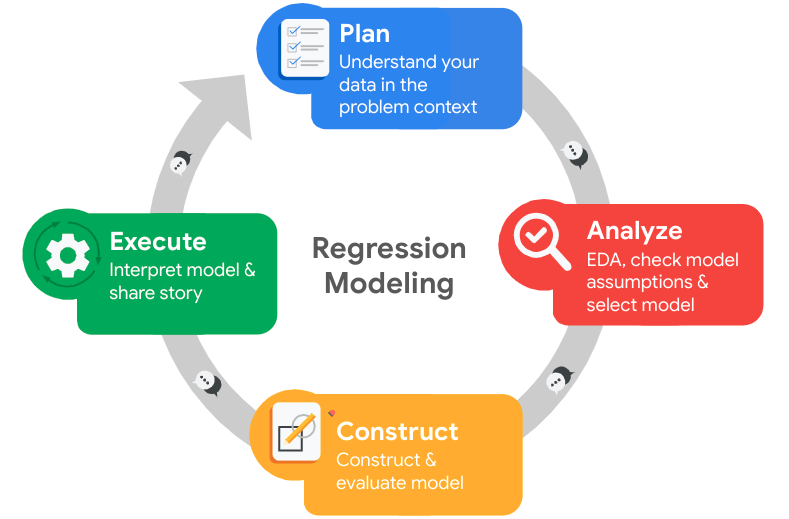

# **Pace: Plan**

### Company Background

Salifort Motors is a fictional French-based alternative energy vehicle manufacturer. Its global workforce of over 10,000 employees research, design, construct, validate, and distribute electric, solar, algae, and hydrogen-based vehicles. Salifort’s end-to-end vertical integration model has made it a global leader at the intersection of alternative energy and automobiles.

### Project Objective
 
The main objective of this project is:
1. Analyze the provided HR dataset to understand the factors behind employee turnover
2. Recommend key actions to remediate employee retention based on the data analysis
3. Design a model that predicts whether an employee will leave the company based on their department, number of projects, average monthly hours, and other features.

***Post-script:** As explained in the project summary, Project Objective 3 cannot be executed faithfully due to ethical implication for a prediction model*

### Ethical Consideration

When analyzing an HR dataset, it is important to take into consideration the anonymity and privacy of all employees within the company to avoid re-identification and data breaches that could lead to discrimination, legal liability, and loss of trust.

This dataset does not include any direct identifiers, such as names, employee ID, or any other identifiable information to be dropped.

### Understanding the Data

The dataset that we'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

## Data Exploration (Initial EDA and data cleaning)

### Imported Packages
Below are the packages used throughout this analysis.

In [1]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import scipy.stats as stats
from scipy.stats import kruskal

!pip install scikit-posthocs;
from scikit_posthocs import posthoc_dunn

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Load Dataset
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("/kaggle/input/datasets/leviiiest/salifort-motor-hr-dataset/HR_capstone_dataset.csv")

/kaggle/input/datasets/leviiiest/salifort-motor-hr-dataset/HR_capstone_dataset.csv


### Gather basic information about the data

In [2]:
# Display first few rows of the dataframe
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
# Gather basic information about the data
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [4]:
# Gather descriptive statistics about the data
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [5]:
# Display all column names
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [6]:
# Rename columns as needed
### YOUR CODE HERE ###
df0 = df0.rename(columns={'satisfaction_level':'satisfaction',
                    'last_evaluation':'performance',
                    'number_project':'project_count',
                    'time_spend_company': 'tenure',
                         'Department': 'department',
                         'average_montly_hours': 'average_monthly_hours',
                         'Work_accident': 'work_accident'})

# Display all column names after the update
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction', 'performance', 'project_count', 'average_monthly_hours',
       'tenure', 'work_accident', 'left', 'promotion_last_5years',
       'department', 'salary'],
      dtype='object')

### Check missing values
Check for any missing values in the data.

In [7]:
# Check for missing values
### YOUR CODE HERE ###
df0.isna().sum()

satisfaction             0
performance              0
project_count            0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates
Check for any duplicate entries in the data.

In [8]:
# Check for duplicates
### YOUR CODE HERE ###
dup = df0.duplicated()
dup.value_counts(normalize=True)

False    0.799453
True     0.200547
Name: proportion, dtype: float64

In [9]:
# Inspect some rows containing duplicates as needed
### YOUR CODE HERE ###
df0[dup].sort_values(by=['satisfaction','performance', 'department']).head(16)

,satisfaction,performance,project_count,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
12030,0.09,0.62,6,294,4,0,1,0,accounting,low
14241,0.09,0.62,6,294,4,0,1,0,accounting,low
12071,0.09,0.77,5,275,4,0,1,0,product_mng,medium
14282,0.09,0.77,5,275,4,0,1,0,product_mng,medium
12652,0.09,0.77,6,290,4,0,1,0,technical,medium
14863,0.09,0.77,6,290,4,0,1,0,technical,medium
12278,0.09,0.78,6,254,4,0,1,0,support,low
14489,0.09,0.78,6,254,4,0,1,0,support,low
12397,0.09,0.79,6,293,5,0,1,0,sales,low
12477,0.09,0.79,6,275,4,0,1,0,sales,low


Upon initial data inspection, approximately 20% of the rows were exact duplicates across all features. In a simulated HR environment, this likely represents logging errors or system double-submitting. The indices are exactly 2211 apart, so it is very likely a pipeline error. 
To prevent overfitting on duplicated rows and ensure robust statistical tests, these duplicates were dropped. Future data collection and analysis should verify the source pipeline to prevent duplicates.

In [10]:
# Drop duplicates and save resulting dataframe in a new variable as needed
### YOUR CODE HERE ###
df = df0.drop_duplicates().copy()

# Display first few rows of new dataframe as needed
### YOUR CODE HERE ###
df.head()

,satisfaction,performance,project_count,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

In [11]:
def detect_outliers_iqr(df):
    """
    Detects outliers in all numeric columns using the IQR method.
    Returns a DataFrame with boolean True where outliers exist.
    """
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = numeric_df.quantile(0.25)
    Q3 = numeric_df.quantile(0.75)
    
    # Calculate IQR
    IQR = Q3 - Q1
    
    # Define outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Return boolean mask: True if value is an outlier
    outliers_mask = (numeric_df < lower_bound) | (numeric_df > upper_bound)
    
    return outliers_mask

# Example usage:
outliers = detect_outliers_iqr(df)
print(outliers.sum()) # Count outliers per column

satisfaction                0
performance                 0
project_count               0
average_monthly_hours       0
tenure                    824
work_accident            1850
left                     1991
promotion_last_5years     203
dtype: int64


***Note:** Only tenure has meaningful outliers since the 'work_accident', 'left', 'promotion_last_5years' columns are binary values.

<Axes: xlabel='tenure'>

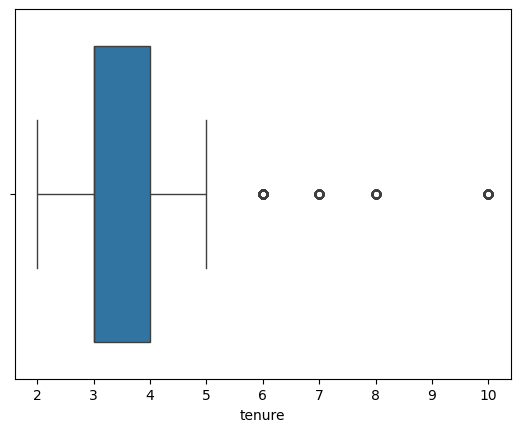

In [12]:
# Boxplots for all meaningful outliers in df
sns.boxplot(data=df, x='tenure')

The distribution of tenures within Salifort Motors is centered at 3-4 years of tenure, and employees working beyond their 5th tenure is considered an outlier based on the boxplot above.

# pAce: Analyze Stage
## Literature Review on Attrition Drivers

The data in this analysis is cross-sectional data that is collected at a single point in time. While the data may reveal the differences between employees at a single point in time, this data is unable to explain a cause-and-effect relationship between variables. In the purpose of overcoming this limitation, we will rely on previous literature to explain patterns and trends that are present within this dataset to draw a proper conclusion on the factors behind employee attrition in Salifort Motors.

Generally, attrition is a complex phenomenon driven by multiple variables, either personal or organizational. We must first acknowledge that it is unethical to maintain retention by manipulating employees and their personal decisions, and actionable steps to curb attrition must be taken within ethical guidelines. Considering the ethics of labor, employers and management must revise policies in compliance with the labor laws, employee rights, and employee well-being.

### 1. The Non-Linear Relationship Between Workload and Turnover

Traditional assumptions on the relationship between workload and turnover mostly agree that there is an overworking threshold, where employees will actively seek a way out. While this assumption can be true, a recent study shows a more complex relationship between these variables, where attrition peaks on both ends of the spectrum. In a recent survey by Samašonok 2024, "inappropriately distributed workload" and "lack of meaningful engagement" are identified as critical drivers of turnover, noting that employees leave not just because of too much work, but because of a lack of challenge and professional growth. This aligns with the findings from the Niagara Institute, where boredom and lack of engagement are the leading causes of attrition. Employees who feel their skills are underutilized often disengage and seek new opportunities. Conversely, the Niagara Institute highlights that unmanageable workloads and unrealistic expectations are primary causes of burnout, leading to a "Great Detachment" where employees actively search for exits.

### 2. The Role of Organizational Support and Flexibility

Both Niagara Institute and Samašonok converge on the idea that the management of workload is more critical than the workload itself. The Niagara Institute argues that retention improves when organizations provide psychological safety, flexible scheduling, and clear prioritization frameworks to help employees manage demands. Similarly, Samašonok (2024) concludes that retention strategies must include "flexible approaches to work organization" and "recognition of efforts" to mitigate the negative effects of high workload or lack of engagement. Spring Health (2025) notes that "unmanageable workloads" are a primary driver of burnout, affecting 58% of the workforce, and that burnout is often a systemic issue rather than an individual resilience problem. When evaluation systems prioritize quantity of output (e.g., project count) over quality of life or long-term sustainability, employees are incentivized to overwork to maintain their high-performance ratings. 

### 3. Lack of Career Development Opportunities

The Niagara Institute and Spring Health articles highlight that "lack of career development" and "limited opportunities for professional growth" are primary drivers of disengagement and turnover. The literature suggests that when high effort is not matched by proportional rewards (such as promotions, flexible schedules, or recognition), employees experience a breach of the "psychological contract." Samašonok (2024) highlights that underestimation of work results and lack of recognition are the top external factors driving turnover. In a system where the only visible metric of success is "hours logged" or "projects completed," employees may feel that their well-being is being exploited rather than their skills being developed.

In conclusion, attrition risk is tied to multiple factors, but points to the overall company policy as a primary factor. Inappropriate workload distribution, where employees are underutilized or overutilized, leads to an increase in attrition risk due to unmet expectations and needs. These patterns will be the precursor to our analysis in evaluating the factors behind Salifor Motors' attrition.

## Salifort Motors' Overall Turnover Rate

In [13]:
t_rate = df['left'].value_counts(normalize=True)
t_count = df['left'].value_counts()
print(f'Total Stay: {t_count[0]:.0f}\n')
print(f'Total Left: {t_count[1]:.0f}\n')
print(f'Turnover Rate: {t_rate[1]:.2%}')

Total Stay: 10000

Total Left: 1991

Turnover Rate: 16.60%


With almost 12000 employees recorded in this dataset, a 16.6% turnover rate is generally costly for a company. Analyzing the attrition factors within Salifort Motors will prove useful in identifying key steps to increase retention before we construct a proper model.

## Results and Findings

### 1. Overworking Culture

By analyzing the average monthly hours of the employees within Salifor Motors, we detected a very severe overworking culture within Salifort Motors. Two primary quantitative indicators signal the presence of an overworking culture within Salifort Motors:

*  **Excessive Working Hours**: The average monthly working hours significantly exceed global health standards. Data indicates that 67% of the workforce is working more than the legal limit set by French authorities, 170 hours per month.
*  **Unhealthy Working Expectations**: The evaluation metrics within Salifort Motors either expect long working hours or that long working hours are needed to meet expectations. The high-performing workers are mostly overworked.

### 1.1 Overtime Analysis

To assess Salifort's 'grind culture,' we need to take into account the appropriate labels:

* **Healthy (124 - 152):** The legal standard working time in France is 35 hours per week. Converting to months ($35 \times 52 / 12$) aggregates to ~152 hours. Accounting for the statutory 5 weeks of paid annual leave ($35 \times 47 / 12$), the effective average drops to ~137 hours, with a safe operational floor around 124 hours. Values below 124 are flagged as underworking
* **Overtime (152 - 170):** This range accounts for the 220-hour annual overtime cap. The maximum legal yearly hours are $1,820 \text{ (standard)} + 220 = 2,040$. Divided by 12, this equals 170 hours/month. Work within this band is legally permissible overtime, provided the 12-week average does not exceed 44 hours.
* **Legal Breach (> 170):** Any average exceeding 170 hours/month mathematically violates the 220-hour annual overtime cap. Even if weekly peaks are managed, a sustained monthly average in this zone proves the company has exceeded the legally allowed overtime quota for the year.

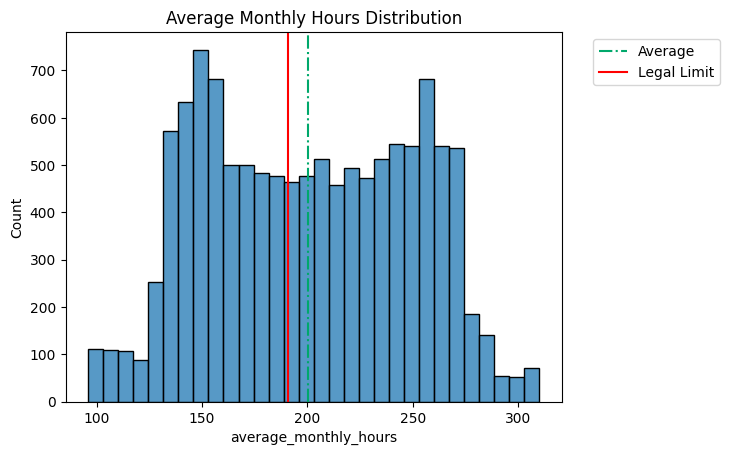

In [14]:
# Boxplot for the overall average working hours
sns.histplot(x=df['average_monthly_hours'], bins=30)

lowest = df['average_monthly_hours'].min()
avg = df['average_monthly_hours'].mean()


# Setting up a healthy boundary
plt.axvline(x=avg, color='#00A86B', linestyle='-.', label='Average') # target lower limit
plt.axvline(x=191, color='r', label='Legal Limit') # legal limit
plt.legend(labels=['Legal Limit', 'Average'])

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Average Monthly Hours Distribution')
plt.show()

The analysis of working hours shows that employees at Salifort Motors are mostly overworked, and the majority are well past the legal threshold set by the French authorities. On top of that, there are no observable overtime guardrails in place at the company. Working above 238 hours on average should be an extreme outlier, but such is not the case, as the histogram shows.

While this visual confirms the severity of the issue, the next step is to quantify exactly how many employees fall into these critical zones and identify which departments are driving this trend.
We will take into account these labels too:

* **Negligence (190 - 220):** As per the hard limit of 48 hours per week working limit in France. Note that the 48-hour limit should also comply with the 220-hour annual overtime limit. Breaching this threshold means a constant violation of the 48-hour weekly limit of working.
* **Critical Violation (>220):**  Undermines employee rights completely. This exceeds the 48-hour absolute weekly limit ($48 \times 52 / 12 = 208$). It also enters the WHO "danger zone" (>55 hours/week or >240 hours/month) for severe health risks. Sustained averages here imply 7-day workweeks and 14+ hour days, violating mandatory daily (11h) and weekly (35h) rest periods.

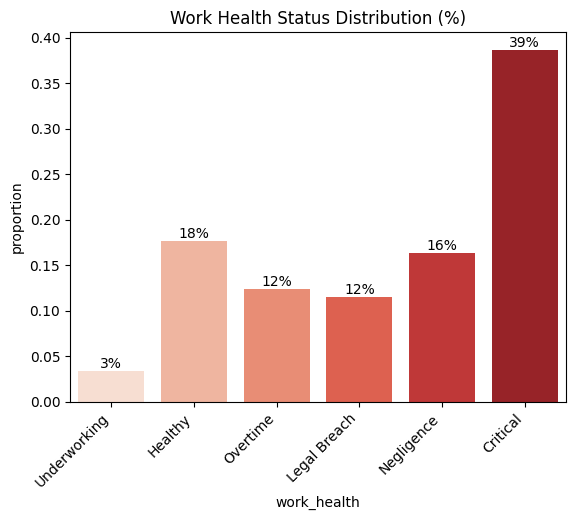

In [15]:
# Make a function to identify work health status
min_work = df['average_monthly_hours'].min()
max_work = df['average_monthly_hours'].max()
bins = [0, 124, 152, 170, 190, 220, max_work]
labels = ['Underworking', 'Healthy', 'Overtime', 'Legal Breach', 'Negligence', 'Critical']
df.loc[:, 'work_health'] = pd.cut(df['average_monthly_hours'],
                            bins=bins,
                            labels=labels,
                            right=True)

prop = df['work_health'].value_counts(normalize=True).reset_index()

plt.figure()
ax = sns.barplot(data=prop.sort_values(by='proportion'), x='work_health', y='proportion',
            hue='work_health', palette='Reds')
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2, 
        height,
        f'{(height * 100):.0f}%', 
        ha='center', 
        va='bottom', 
        fontsize=10,
        color='black'
    )

x_axis = ax.get_xticks()
ax.set_xticks(x_axis)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');

plt.title('Work Health Status Distribution (%)')
plt.show()

Approximately 67% of the employees in Salifort Motors are working above 170 hours per month, above France's legal limit. Within the limitations of the data provided, we cannot accurately infer the real reason behind such numbers, but the fact that 67% are overworking suggests systemic issues: possibly excessive overtime culture, insufficient staffing, or economic pressure forcing long hours. However, the lack of overtime guardrails to prevent such long hours is still a pressing issue that needs remediation to avoid legal penalties and protect worker health.

### 1.2 Systemic Red Flag

When analyzing the performance scores in this data, two limitations should be taken into account:
1. The evaluation methodology for the performance score is not disclosed, and thus, the interpretation of the data may be inaccurate.
2. The data is cross-sectional, and we are unable to access the longitudinal performance score to identify trends across an employee's whole tenure.

However, the analysis reveals a distinct 'smoking gun'. There is a significant difference between the performance scores for employees across their working health conditions, which reflects on a normalized working culture at a systemic level.

<Axes: xlabel='performance', ylabel='Count'>

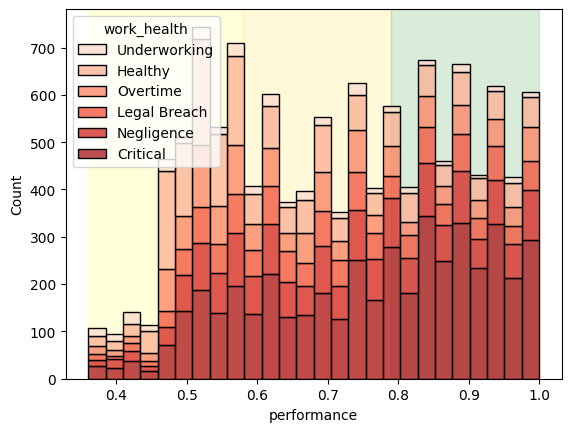

In [16]:
df.loc[:, 'tier'] = pd.cut(df['performance'], bins=3, labels=['Low', 'Medium', 'High'])

# Setting up a healthy boundary
plt.axvspan(df[df['tier'] == 'Low']['performance'].min(),
            df[df['tier'] == 'Medium']['performance'].min(),
            color='yellow',
            alpha=0.15, label='Low') # Low perf
plt.axvspan(df[df['tier'] == 'Medium']['performance'].min(),
            df[df['tier'] == 'High']['performance'].min(),
            color='gold',
            alpha=0.15, label='Medium') # Medium perf
plt.axvspan(df[df['tier'] == 'High']['performance'].min(),
            df[df['tier'] == 'High']['performance'].max(),
            color='green',
            alpha=0.15, label='High') # High perf

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


sns.histplot(data=df, x='performance', hue='work_health', multiple='stack', palette='Reds')

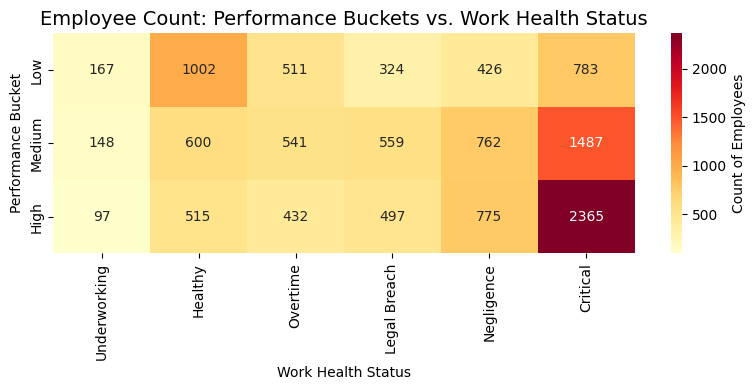

In [17]:
pivot_data = pd.crosstab(df['tier'], df['work_health'])

plt.figure(figsize=(8, 4))
sns.heatmap(pivot_data, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': 'Count of Employees'})

plt.title('Employee Count: Performance Buckets vs. Work Health Status', fontsize=14)
plt.xlabel('Work Health Status')
plt.ylabel('Performance Bucket')
plt.tight_layout()
plt.show()

By comparing the evaluation scores of Salifort Motors employees with their work health status, the analysis shows a highly scattered distribution across the dataset. All employees in the dataset fall within the range of 0.4 to 1.0 evaluation scores, regardless of their work health status or productivity. This means employees can get a good evaluation score without overworking.

However, considering the shape of the histogram:
* **Overworkers Dominate High Performance Tier:** There is a significantly higher density of overworkers in the high-performance (>0.8 performance) bin. This group significantly outnumbers healthy or underworking peers in the highest productivity ranges.
* **Overworking is Prevalent Across the Board:** On top of that, overworking employees are also present in mid-to-low performance ranges, but more concentrated at the high performance bin. 

To statistically validate that the overworkers are not getting a high evaluation score by chance, a non-parametric Kruskal-Wallis H test was selected. This test is robust to non-normal data and is designed to determine if there are statistically significant differences in the median ranks of a continuous variable (performance score) across three or more independent groups (work health categories).

**Null Hypothesis** ($H_0$): The median performance scores are equal across all four work health groups.

**Alternative Hypothesis** ($H_1$): At least one work health group has a different distribution of performance scores compared to the others.

In [18]:
health_group = df.groupby('work_health', observed=False)['performance']
data_health = [group.values for name, group in health_group]
h_stat, p_val = kruskal(*data_health)

h_stat, p_val_kw = kruskal(*data_health)
print(f"--- Kruskal-Wallis H Test Results ---")
print(f"H-Statistic: {h_stat:.4f}")
print(f"P-Value: {p_val_kw:.2e}")
if p_val_kw < 0.05:
    print("Result: SIGNIFICANT. Performance scores differ significantly by Work Health group.")
else:
    print("Result: NOT SIGNIFICANT.")

--- Kruskal-Wallis H Test Results ---
H-Statistic: 854.6545
P-Value: 1.73e-182
Result: SIGNIFICANT. Performance scores differ significantly by Work Health group.


The Kruskal-Wallis H test results provide overwhelming statistical evidence to reject the Null Hypothesis ($H_0$).

With an H-Statistic of 854.655, there is a high variance in the median performance score between the work health groups. Furthermore, a p-value of $1.73 \times 10^{-182}$ highlights the very low probability that the differences occurred by chance. This confirms that working hours are a statistically significant predictor of performance score distribution at Salifort Motors.

This statistical significance validates the earlier histogram observation: the concentration of "Overworkers" (specifically those in the $>170$ hrs/month and beyond) in the high-performance bins is not random noise. It is a real, measurable trend in the dataset.

Despite the limited context of how performance is evaluated, the data reflect the current evaluation system rewarding severe overworking behaviour. Employees exceeding the legal limit (~170 hrs) or medical safety limit (238 hrs) are systematically achieving higher evaluation scores than their "Healthy" or "Underworking" peers.

Since the Kruskal-Wallis test only tells us that a difference exists, not where it lies, a Post-Hoc Dunn’s Test with Bonferroni correction is recommended. This will pinpoint exactly which pairs of groups differ significantly.

In [19]:

p_val_phd = posthoc_dunn(df, val_col='performance', group_col='work_health', p_adjust='bonferroni')

print(f"--- Post-Hoc Dunn Results --- \n{p_val_phd}")

--- Post-Hoc Dunn Results --- 
              Underworking        Healthy      Overtime  Legal Breach  \
Underworking  1.000000e+00   1.000000e+00  8.734778e-04  6.546181e-12   
Healthy       1.000000e+00   1.000000e+00  2.025896e-10  1.728796e-31   
Overtime      8.734778e-04   2.025896e-10  1.000000e+00  1.522827e-05   
Legal Breach  6.546181e-12   1.728796e-31  1.522827e-05  1.000000e+00   
Negligence    1.947378e-17   2.742414e-52  2.660795e-12  6.704188e-01   
Critical      8.555325e-40  3.687156e-153  1.111381e-53  4.883615e-19   

                Negligence       Critical  
Underworking  1.947378e-17   8.555325e-40  
Healthy       2.742414e-52  3.687156e-153  
Overtime      2.660795e-12   1.111381e-53  
Legal Breach  6.704188e-01   4.883615e-19  
Negligence    1.000000e+00   5.346846e-14  
Critical      5.346846e-14   1.000000e+00  


The post-hoc Dunn test confirms statistically significant differences in performance scores across working condition groups, with p-values far below the $p < 0.05$ threshold for nearly all comparisons, many as low as $10^{-50}$ or smaller.

These extreme p-values confirm that the observed performance disparities between groups are not due to chance. Notably, employees in "Critical" and "Legal Breach" work health statuses consistently achieve the highest performance scores, particularly in the "High" performance bucket (2,365 and 775 employees, respectively), while those in "Underworking" and "Healthy" conditions cluster in lower performance tiers.

This pattern suggests that Salifort Motors’ current performance evaluation system systematically favors employees operating under legally non-compliant (>191 hours) and medically at-risk (>238 hours) workloads. To ensure long-term productivity, employee well-being, and legal compliance, the evaluation framework must be recalibrated to prioritize health sustainability over raw output volume.

However, this does not prove causation. Further analysis of individual performance scores, workload metrics, and evaluation criteria is needed to determine whether the system systematically favors unhealthy work patterns. A longitudinal study is highly recommended to better understand the reason behind this pattern.

### 1.3 Attrition Analysis on Overworking

Given that high performance is statistically correlated with overworking, this segment transitions to analyzing attrition rates across the defined work health  and performance bins. Previous studies support the idea that both underworking and overworking employees have high turnover due to the former being disengaged and the latter being burnt out.

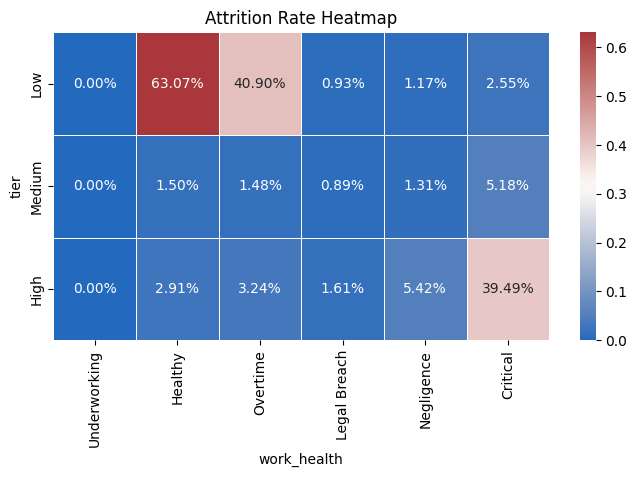

In [20]:
attrition = pd.crosstab(index=df['tier'], columns=df['work_health'], 
            values=df['left'], aggfunc='mean')

plt.figure(figsize=(8, 4))
sns.heatmap(attrition, annot=True, fmt='.2%', cmap='vlag', linewidths=.5)
plt.title('Attrition Rate Heatmap')
plt.show()

Based on the attrition rate heatmap, we can identify 3 of our biggest turnover groups:
* **Healthy, Low Performance (63% turnover rate):** Note that this group has the third highest count of employees in the dataset; 1001 workers. 632 employees' turnover is from this group.
* **Overtime, Low Performance (41% turnover rate):** Despite the high attrition rate, this group only consists of 511 employees in the dataset, including 209 who left.
* **Critical, High Performance (~40% turnover rate):** This group is actually the biggest attrition group, with 934 employees who left.

While this analysis confirms that overworking drives talent loss in Salifort Motors, the key takeaway from this analysis is the critically severe overworking culture within this company. The goal must be to decouple high performance from overwork to ensure long-term organizational health, alongside establishing overtime guardrails to prevent longer working hours from being normalized. 

Note that due to the limitations of the dataset, we cannot accurately pinpoint the reason behind overworking in Salifort Motors. Despite the previous analysis, we only established that working more hours is rewarded with a high evaluation score, and the data does not reveal why employees are working these hours. It is recommended for the HR department to investigate further into the root cause of overworking when revising the overtime policies to make the best decision with both the employee and company in mind.

### 2. Poor Workload Distribution

An interesting observation from this group is that the attrition rate is exclusively high in the high-performance group across the Critical overtime workers, and the inverse for both the Healthy and Overtime groups, with high attrition rates within the low-performance group. By analyzing the workload distribution, using the total number of projects an employee contributed to as the investigated variable, the data shows that:

* **The Low Performance sub-group is under-utilized:** There is an observable pattern where the low-performance, Healthy/Overtime groups have a higher proportion of employees who are contributing to minimal project counts compared to others. Further investigation into the details of projects this group contributed to will reveal a more meaningful conclusion on the under-utilization of this group.
* **The High Performance sub-group is over-utilized:** On top of the distinct majority of high-performers densely populating the Critical group, they're also the majority of employees that works on 4 to 7 projects. In relation to the previous analysis, it is strongly believed that Salifort Motors is systematically normalizing a severe overworking culture by favoring a high workload and providing no guardrails to protect employees' health.

This pattern of under- and over-utilization of employees is observed in many studies on the factors driving attrition. The leading theory is that underworkers may feel disengaged and leave to find a more meaningful career. Note that this does not apply to all the underworkers, as we can still observe several underworkers across that stayed.

Understanding the work distribution will help us solve both the burnout issue and the underutilization issue by setting a stricter minimum and maximum project counts.

Dataset limitations:
* **The roles or positions of each employee are not provided**. This information is crucial in determining the fairness of workload distribution. 
* **Project details are not provided.** Details on the projects employees contributed to will give further context to the massive variance in effort, duration, and cognitive load. We are a
* **Project status is not provided.** This could be the biggest piece of the puzzle; the success or failure to meet the project objective could be an integral weightage for performance.

To address this limitation, future analyses need to take into account the limitations of this analysis and present a more robust dataset.


### 2.1 Project Count Analysis
The previous analysis on performance and work health status reveals that despite the correlation between overworking and performance score, it is not a clear-cut relationship. The existence of high-performing underworkers and low-performing overworkers strongly suggests that project load is the missing variable.

By analyzing the number of projects an employee manages, we can determine if the workload is appropriate or evenly distributed, and reveal if project counts lead to under- or over-utilization of employees.

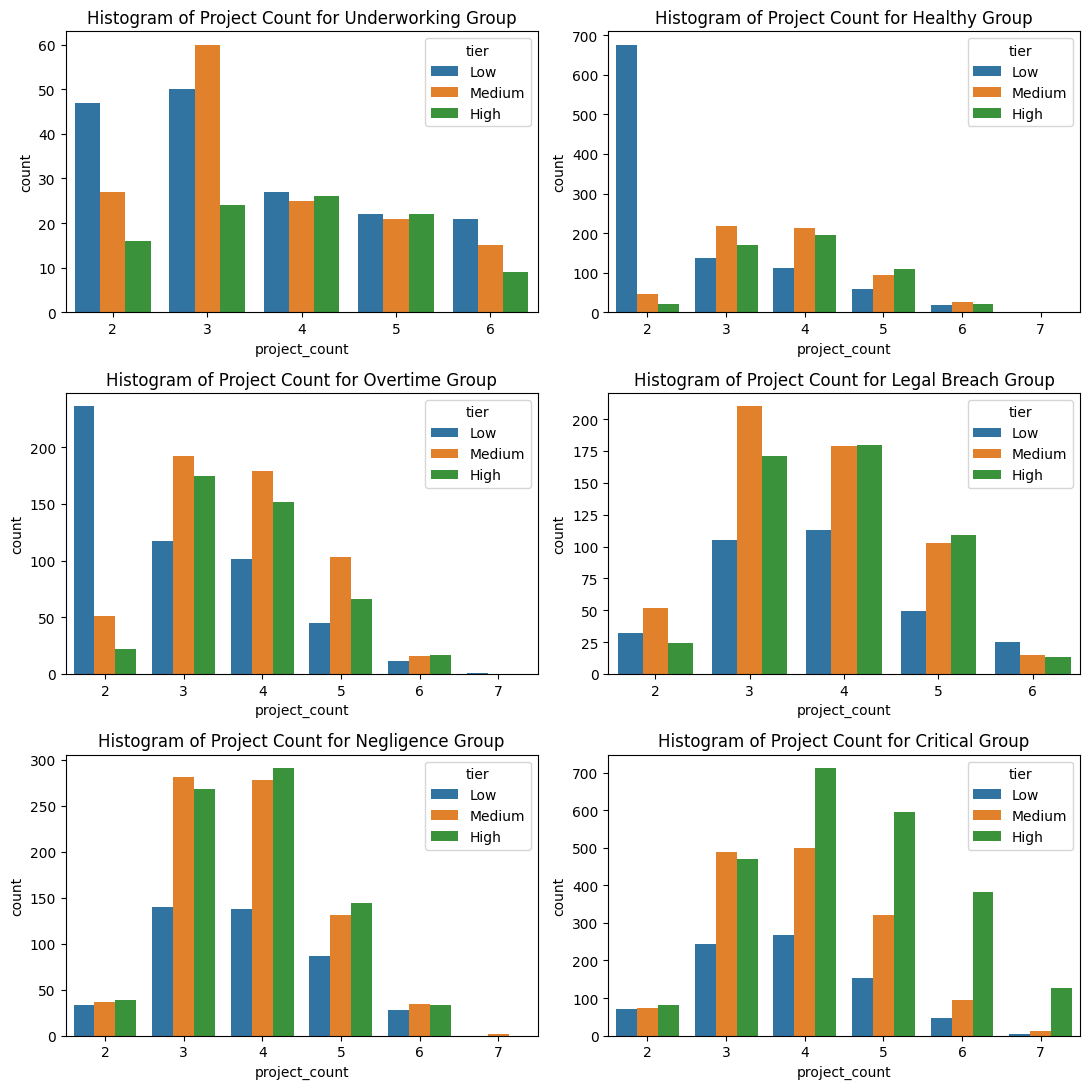

In [21]:
list_col = df['work_health'].copy().sort_values().unique()

fig, ax = plt.subplots(3,2, figsize=(11, 11))
axes = ax.flatten()

for i in range(0,len(list_col)):
    mask = df['work_health'] == list_col[i]
    sns.countplot(data=df[mask], x='project_count', hue='tier', ax=axes[i])
    axes[i].set_title(f"Histogram of Project Count for {list_col[i]} Group")

#axes[5].set_title("Distribution of Project Count by Performance Tier")
plt.tight_layout()

By observing the histograms of project counts by work health groups, we can see an uneven workload distribution. Key observations from this visualization:

* **The Top 3 Attrition Risk has Uneven Work Distribution:** Comparing our previous interest groups with the highest attrition rate, these groups do not follow a proportional distribution across project counts.
* **High Density of Employees Working Minimally:** A significant proportion of the workload for low-performing, Healthy and Overtime groups, is working on 2 projects within their full tenure.
* **Disproportionate Workload in High Performance Group:** Exclusively in the Critical, High-performance group, we can see that the majority of the workers in this group are working >4 projects, and the highest number of employees working on 7 projects are in this group.
* **High Density of Low Project Contribution in Low-Performance Group:** There are around 700 and 300 employees in the low-performance Healthy group and the low-performance Overtime group, respectively. That is around 70% and 60% of the total employees in both respective groups, and roughly 30% of the low-performance tier.
* **Variation of Performance Trends:** In thresholds below 'Legal Breach', there is a distinct variation in performance patterns. After the Legal Breach threshold, higher project counts have a higher proportion of high performers. Despite our limitation to make a clear causal relationship between the variables, there is a strong correlation that supports our previous theory that there is a systemic red flag that normalizes overworking in this company.

These pattern supports our assumptions of under- and over-utilization of employees as discussed in previous studies. 

To statistically validate that the higher project counts are not getting a high evaluation score by chance, the Kruskal-Wallis H test is conducted again. 

**Null Hypothesis** ($H_0$): The median performance scores are equal across all project contributions.

**Alternative Hypothesis** ($H_1$): At least one of the project contribution counts has a different distribution of performance scores compared to the others.

In [22]:
project_gp = df.groupby('project_count')['performance']
data_pro = [group.values for name, group in project_gp]
h_stat, p_val = kruskal(*data_pro)

print(f"--- Kruskal-Wallis H Test Results ---")
print(f"H-Statistic: {h_stat:.4f}")
print(f"P-Value: {p_val_kw:.2e}")
if p_val_kw < 0.05:
    print("Result: SIGNIFICANT. Performances differ significantly by Project Count.")
else:
    print("Result: NOT SIGNIFICANT.")

--- Kruskal-Wallis H Test Results ---
H-Statistic: 1328.1058
P-Value: 1.73e-182
Result: SIGNIFICANT. Performances differ significantly by Project Count.


The Kruskal-Wallis H test results provide overwhelming statistical evidence to reject the Null Hypothesis ($H_0$).

With an H-Statistic of 1328.1058, there is a high variance in the median performance score between the project counts. Furthermore, a p-value of $1.73 \times 10^{-182}$ highlights the very low probability that the differences occurred by chance. This confirms that project counts are a statistically significant predictor of performance score distribution at Salifort Motors. This test further strengthens the assumption that Salifort Motors favors overworkers without actively complying with the legal standard.

A Post-Hoc Dunn’s Test with Bonferroni correction is implemented. This will pinpoint exactly which pairs of groups differ significantly.

In [23]:
p_val_phd = posthoc_dunn(df, val_col='performance', group_col='project_count', p_adjust='bonferroni')

print(f"--- Post-Hoc Dunn Results --- \n{p_val_phd}")

--- Post-Hoc Dunn Results --- 
               2              3              4              5              6  \
2   1.000000e+00  4.794179e-155  1.598759e-200  7.572802e-202  9.380482e-143   
3  4.794179e-155   1.000000e+00   1.302454e-04   1.423872e-11   8.491194e-13   
4  1.598759e-200   1.302454e-04   1.000000e+00   1.492993e-02   2.099855e-05   
5  7.572802e-202   1.423872e-11   1.492993e-02   1.000000e+00   2.504143e-01   
6  9.380482e-143   8.491194e-13   2.099855e-05   2.504143e-01   1.000000e+00   
7   4.029151e-81   4.255683e-23   6.049815e-18   9.439321e-14   3.457574e-09   

              7  
2  4.029151e-81  
3  4.255683e-23  
4  6.049815e-18  
5  9.439321e-14  
6  3.457574e-09  
7  1.000000e+00  


The post-hoc Dunn test confirms statistically significant differences in performance scores across project counts, with p-values far below the $p < 0.05$ threshold for nearly all comparisons. This means the differences did not happen by chance, and our observation that high performers densely populates Citical threshold and > 5 project count group.

However, this does not prove causation. Further analysis of individual performance scores, workload metrics, and evaluation criteria is needed to determine whether the system systematically favors unhealthy work patterns. Further study is highly recommended to better understand the reason behind this pattern.

### 2.2 Workload and Retention Analysis
Recall that previous analysis reveals the top 3 highest attrition risk group:
* Low-Performance, Healthy Group (63% attrition rate)
* Low-Performance, Overtime group (41% attrition rate)
* High-Performance, Critical group (40% attrition rate)

Analysis on project count reveals that within these groups, the pattern suggests over-utilization and underutilization in high-performance and low-performers groups, respectively. Having established this relationship, the next critical step is to determine how these workload levels impact employee retention to bridge the analysis together. We will now analyze the attrition rate across each project count to see if excessive or insufficient project loads drive employees to leave.

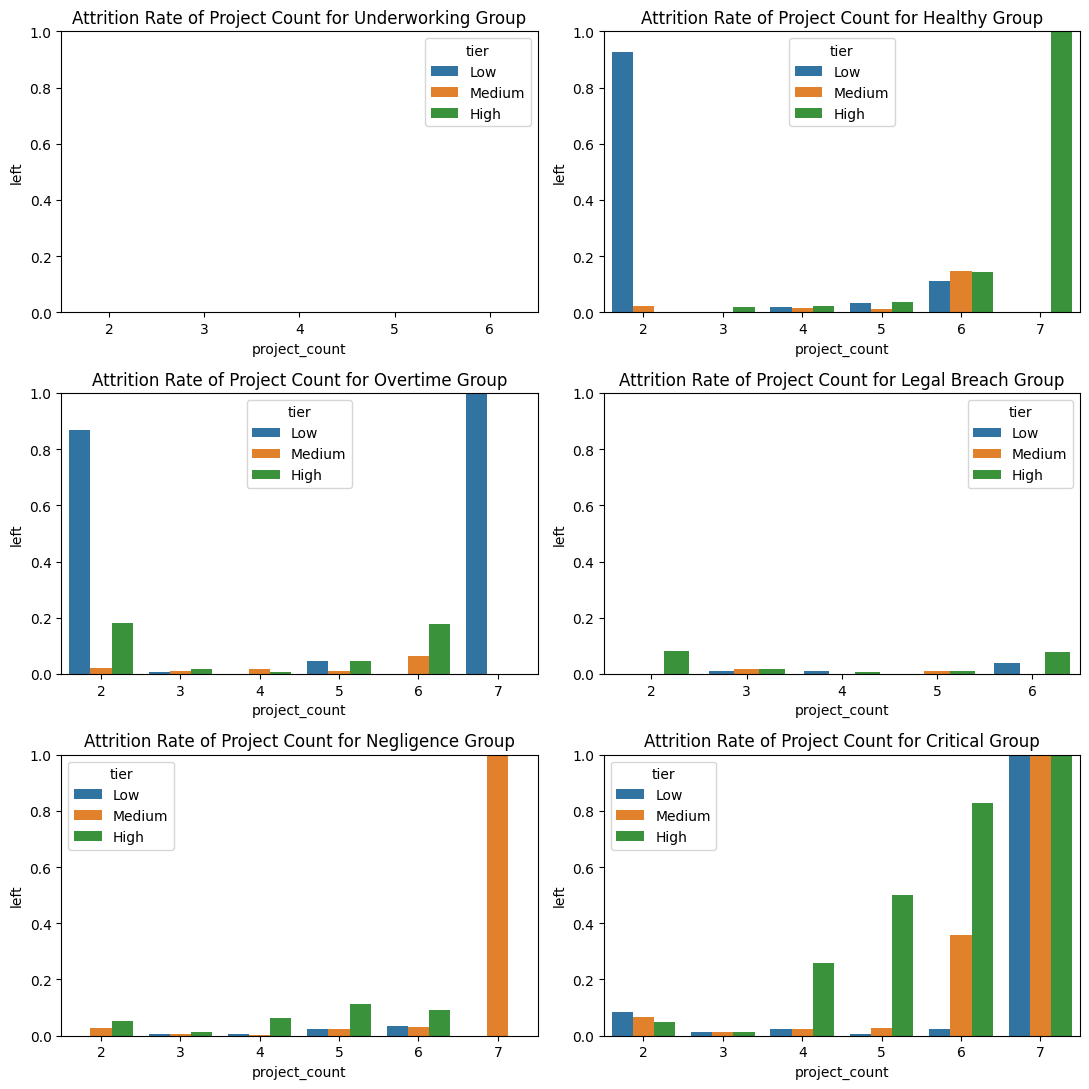

In [24]:
test = df['work_health'].copy().sort_values().unique()

fig, ax = plt.subplots(3,2, figsize=(11, 11))
axes = ax.flatten()

for i in range(0,6):
    mask = df['work_health'] == test[i]
    sns.barplot(data=df[mask], x='project_count', y='left', errorbar=None, hue='tier', ax=axes[i])
    axes[i].set_ylim(0, 1.0)
    axes[i].set_title(f"Attrition Rate of Project Count for {test[i]} Group")

#sns.heatmap(data= pd.crosstab(index=df['tier'], columns=df['project_count'],
#                              values=df['left'], aggfunc='mean'),
#            annot=True, fmt='.2%', cmap='vlag', linewidths=.05,
#            ax=axes[5]
#           )
#axes[5].set_title("Attrition based on\nProject Count by Performance Tier")
plt.tight_layout()

These are the patterns observed in the visualization above:
* **Absolute Attrition Threshold:** Employees contributing to 7 projects have a 100% attrition rate.
* **Underutilization Attrition:** Exclusive in our low-performance attrition groups, employees with 2 project counts have an >80% attrition rate.
* **Critical Overworking as a Moderating Variable:** Exclusively in the Critical group, attrition risks rise as project count rises. This pattern is not present in other groups.

This trend suggests an underlying issue of over- and under-utilization discussed in previous studies. Low-performance and Health/Overtime groups experience high attrition due to disengagement and a lack of purpose or reason to stay with the company. High-performance, Critical group shows heightened attrition risk when they contribute to more projects.

The main issue with this overall trend is:
1. Salifort Motors is losing top talent due to mismanagement of workload distribution and an overworking culture that cascades into burnout. Losing top talent means losing institutional knowledge. Eventually, there will be knowledge gaps due to high attrition.
2. Losing low-performers by a large margin is still costly; the company loses the potential carried by this group. 

This highlights a priority actionable step:
* Remediating the company's expectations and evaluation system to put employees' rights on a higher pedestal.
* Management must also consider revising the current workload distribution framework to curb overutilization of high-performers while keeping low-performers engaged.
* On top of establishing overtime guardrails, HR must also inspect employees' capacity and consider the need for re-skilling and/or upskilling employees to prevent role mismatches.

### 3. Low Internal Mobility

In this analysis, there is a strong indication of a normalized grind culture facilitated by a systematic red flag; high workload is favored by Salifort Motors, without guardrails to keep employees working safely.

Research indicates that a healthy internal promotion rate for established companies typically falls between 6% and 8% (Society for Human Resource Management, 2024). Furthermore, providing clear career development paths is critical for retention, with 94% of employees stating they would stay longer at an organization that invested in their learning (LinkedIn Learning, 2023). This is the standard "baseline" used by HR professionals to gauge organizational health.

A low rate can lead to disengagement, as high performers may feel their efforts aren't recognized or that the path to advancement is blocked. To calculate the cumulative promotion probability over the 5-year window, the formula is as follows:

$$ \text{5-Year Promotion Incidence} = \left( \frac{\text{Count of Employees where } \text{promotion\_last\_5\_years} = 1}{\text{Total Count of Employees}} \right) \times 100 $$

In [25]:
five_year_promo = (
    (
        df[df['left']==0]['promotion_last_5years'].sum()
    )/(
        df[df['left']==0]['promotion_last_5years'].count()
    ) * 100
)
print(f'Employee Count: {df[df['left']==0]['promotion_last_5years'].count()}')
print(f'\nPromoted within 5 years: {df[df['left']==0]['promotion_last_5years'].sum()}')
print(f'\n5-Year Promotion Incidence: {five_year_promo}%')

Employee Count: 10000

Promoted within 5 years: 195

5-Year Promotion Incidence: 1.95%


This is the final nail in the coffin. With only 195 out of 10,000 employees promoted within 5 years, the company has a low level of internal mobility. At 1.95% per year, an employee would statistically need 51 years to have a 50% chance of being promoted once. In reality, most employees expect a promotion every 2–4 years. Initial data exploration supports this claim, as employees working above 5 years are considered outliers within Salifort Motors.

A strong case can be made within Salifort Motors: the overutilization of severely overworked employees eventually causes attrition as their efforts go unrecognized, and the underutilization of Healthy employees results in attrition as they are unable to progress in the company.

This issue can be remediated in many ways, but it must be in tandem with overtime guardrail revisions and workload distribution frameworks that put employees' health and rights above productivity.

# paCe: Construct Stage

## Ethical Use & Limitation Statement
Given that employees in Salifort Motors are working above the normal working hours and the legal overtime threshold on average, the ethical risks of constructing a prediction model are:
1. **Unfair incentives to retain employees**: The model might be used strictly to incentivize employees without rectifying humanitarian policies.
2. **Dehumanizing outcomes:**: The model risks being used to manage individual employees through incentives rather than addressing systemic problems, treating retention as a technical problem instead of a management accountability issue.

On top of that, there are multiple dataset limitations worth considering.
1. The abnormality of working hours within this dataset will eventually normalize the same issue again. A more sustainable approach is to improve the current policy before relying on a predictive model.
2. Given the cross-sectional nature of the dataset, models are only able to match attrition profiles between employees instead of calculating real risks.
3. Given the lack of details on employee roles and project details, models cannot reliably predict without context. 

# pacE: Execute Stage
## Insights
The core findings of this analysis reveal 3 prominent patterns that align with the leading factors of attrition (or the leading factors reducing retention): **Severe Overworking Culture**, **Uneven Workload Distribution**, and **Low Internal Mobility and Progression**. 

This analysis implies that Salifort Motors is currently operating under a very unsustainable working culture that burns out its top talents, and at the same time underutilizes employees within normal working thresholds. On top of that, limited progression and internal mobility made it very hard for employees to find a reason to stay, as their efforts are unrecognized.

Despite the limitations of this dataset, the disparity between turnover rates within the interest groups and the broader workforce is substantial. Further investigations with the highlighted issues as the main focus will help steer effective policy-making decisions that benefit the company. 

## Actionable Steps

To reverse this trend, Salifort Motors must immediately prioritize initiatives that address employee well-being, redistribute workloads, and create clear pathways for internal progression.

### 1. Curbing Overtime

Overall, the main issue within Salifort Motors is the severe overworking culture. Recall that employees are working beyond an average of 300 hours per month. The math implies that these employees are working 10 hours every day without weekend breaks. Actionable steps in curbing overtime are:
* **Revising Employee Evaluation Framework:** HR should investigate why overworking is favored and make a data-driven solution to this issue. Without further context, this analysis is limited to recommending that performance evaluation should align with healthy working standards.
* **Physical Overtime Guardrails:** Executives can put forward a policy to curb overtime via physical means. Policies such as scheduled network downtimes, mandatory lights-off hours, or mandatory closing periods will make overtime unfavorable, thus normalizing standard hours
* **Systemic Overtime Guardrails:** Steps must be taken to either recompensate for working hours above 48 hours per week. Employees with severe overworking should not be recompensated with monetary incentives, but with awarded leaves.

### 2. Revising Workload Management

Uneven workload leads to attrition by disengagement or burnout. Further investigation into what causes an uneven workload distribution and how the workload is distributed should take priority. Curbing overtime can also help manage workloads by making it hard to take on too many projects. Aside from that:
* **Increase Manager Accountability:** Managers should be accountable for uneven workload management. Introducing **managerial KPI standards** that include Team Workload as a weightage will help track workload across teams.
* **Consider Outsourcing:** Due to the limitations of the dataset, it is not disclosed whether Salifort Motors recruits contractors or freelancers. However, outsourcing will be a manageable step that can be taken to distribute the workload away from burnt-out employees.

### 3. Increasing Internal Progression

Salifort Motors has an extremely low promotion rate, which will be an issue when employees do not feel recompensed for their efforts. Note that studies show employees expect a promotion at least once every 3 years. To improve internal progression in Salifort Motors:
* **Reskilling Low-Performing Employees:** Reskilling helps keep healthy, low-performing employees engaged and feel seen, thus increasing retention.
* **Upskilling:** A healthy upskilling policy within the company not only keeps the employees engaged, but it's also a valuable perk that increases retention.  
* **Broadbanding:** Introducing a wider salary range within the same position would increase internal progression without creating new seats or ladders for employees to climb.
* **Lateral Mobility:** HR should assess an employee's skill to find eligible adjacent roles outside of their posted department. Lateral mobility is a strategy to keep employees engaged.

## Conclusion

Salifort Motors is currently facing an operational decay due to an unsustainable working culture and stagnating employees. The analysis in this project shows that Salifort Motors normalizes an unhealthy grind culture, with the majority of employees working above the legal limit of overtime set by the French Government. The company's evaluation metrics show a significant correlation to high workload and long working hours, with severe overworkers dominating as high performers compared to the rest. On top of that, Salifort Motors is showing stagnation and promotion bottlenecks across all departments, with only ~1.6% promotions within the last 5 years. These issues cascade into an expectation mismatch that causes attrition as the company fails to be accountable for the employee's interest and health.

Efforts to increase retention must focus on transforming the current overworking culture into a healthier corporate environment. By enforcing limits on overtime, increasing accountability of key personnel, presenting upskilling opportunities, and introducing broadbanding and lateral mobility strategies, the overall dynamic shifts into a sustainable gear.

Actionable steps to remediate retention will benefit the company in the long run by retaining top talent and polishing high-potential employees.

# References

1. **Society for Human Resource Management.** (2024). Employee turnover and retention statistics. https://www.shrm.org/topics-tools/news/benefits-compensation/employee-turnover-statistics
2. **LinkedIn Learning.** (2023). 2023 Workplace Learning Report. LinkedIn. https://www.linkedin.com/business/learning/business/resources/workplace-learning-report
3. **Keystone Partners.** (2025). The High-Performer Burnout Zone: Why Your Best Employees Are at Greatest Risk. https://www.keystonepartners.com/resources/high-performer-burnout-prevention-guide/
4. **Spring Health.** (2025). How to Prevent Employee Burnout at Your Organization. https://www.springhealth.com/blog/employee-burnout-management-prevention
5. **Forbes Human Resources Council.** (2025). How To Address The Silent Burnout Crisis Among High Performers. https://www.forbes.com/councils/forbeshumanresourcescouncil/2025/06/12/how-to-address-the-silent-burnout-crisis-among-high-performers/
6. **Singh, D.** (2019). A literature review on employee retention with focus on recent trends. (Cited in ResearchGate review).
7. **Al-Suraihi et al.** (2021). Employees Retention Strategies and Organizational Performance. (Cited in abacademies.org).
8. **Samašonok, K.** (2024). Employee turnover: Causes and retention strategies. Entrepreneurship and Sustainability Issues, 11(3), 134–148.